#  Application du K-Means — Segmentation Clients

> **Objectif :** Segmenter les clients d'un centre commercial selon leurs caractéristiques  
> (genre, âge, revenu annuel, score de dépenses).  
> On compare trois méthodes d'initialisation ainsi que le `KMeans` de scikit-learn.

---
**Dataset :** `Mall_Customers.csv`  
**Algorithme :** K-Means Clustering  
**Nombre de clusters (k) :** 5  
**Méthodes comparées :** Forgy, Random Partition, K-Means++, Sklearn

## 1. Imports & Dépendances

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans as KMeans_sklearn
from sklearn.metrics import silhouette_score

from k_means import KMeans   #  Implémentation from scratch

## 2. Chargement & Exploration des données

Inspection initiale pour comprendre la structure du dataset avant tout prétraitement.

In [2]:
data = pd.read_csv('Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape :", data.shape)
print("\nTypes :")
print(data.dtypes)
print("\nValeurs manquantes :")
print(data.isnull().sum())
print("\nDoublons :", data.duplicated().sum())

Shape : (200, 5)

Types :
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Valeurs manquantes :
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Doublons : 0


## 3. Prétraitement

Étapes :
- **Suppression** de `CustomerID` (identifiant non informatif)
- **Encodage** de `Gender` (LabelEncoder)
- **Standardisation** des features (StandardScaler) — indispensable pour K-Means qui est sensible aux échelles

In [4]:
# Suppression de l'identifiant
data.drop('CustomerID', axis=1, inplace=True)

# Encodage de Genre
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

# Standardisation
scaler = StandardScaler()
X = scaler.fit_transform(data)

print("Features utilisées :", list(data.columns))
print("Shape après prétraitement :", X.shape)

Features utilisées : ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape après prétraitement : (200, 4)


## 4. K-Means — Implémentation from scratch (3 méthodes d'initialisation)

On entraîne trois variantes avec `k=5` en faisant varier uniquement la méthode d'initialisation  
pour isoler son impact sur la convergence et la qualité du clustering.

### 4.1 — Forgy

In [5]:
model1 = KMeans(k=5, init_method='forgy', random_state=42)
start = time.time()
model1.fit(X)
t1 = time.time() - start
sil1_custom = model1.calculate_silhouette_score(X)
sil1_ref    = silhouette_score(X, model1.labels)
print(f"Temps : {t1:.4f} s  |  Silhouette (maison) : {sil1_custom:.4f}  |  Silhouette (sklearn) : {sil1_ref:.4f}")

Itération 1/100 | Écart : 1.5440 | Stable : 0/5
Itération 2/100 | Écart : 0.3635 | Stable : 0/5
Itération 3/100 | Écart : 0.1865 | Stable : 0/5
Itération 4/100 | Écart : 0.0950 | Stable : 0/5
Itération 5/100 | Écart : 0.0979 | Stable : 0/5
Itération 6/100 | Écart : 0.0636 | Stable : 0/5
Itération 7/100 | Écart : 0.0981 | Stable : 0/5
Itération 8/100 | Écart : 0.2062 | Stable : 0/5
Itération 9/100 | Écart : 0.2099 | Stable : 0/5
Itération 10/100 | Écart : 0.0469 | Stable : 0/5
Itération 11/100 | Écart : 0.0393 | Stable : 0/5
Itération 12/100 | Écart : 0.0000 | Stable : 0/5
Itération 13/100 | Écart : 0.0000 | Stable : 1/5
Itération 14/100 | Écart : 0.0000 | Stable : 2/5
Itération 15/100 | Écart : 0.0000 | Stable : 3/5
Itération 16/100 | Écart : 0.0000 | Stable : 4/5
Itération 17/100 | Écart : 0.0000 | Stable : 5/5

Entraînement terminé — convergence en 17 itération(s)
Temps : 0.0125 s  |  Silhouette (maison) : 0.2776  |  Silhouette (sklearn) : 0.2776


### 4.2 — Random Partition

In [6]:
model2 = KMeans(k=5, init_method='random_partition', random_state=42)
start = time.time()
model2.fit(X)
t2 = time.time() - start
sil2_custom = model2.calculate_silhouette_score(X)
sil2_ref    = silhouette_score(X, model2.labels)
print(f"Temps : {t2:.4f} s  |  Silhouette (maison) : {sil2_custom:.4f}  |  Silhouette (sklearn) : {sil2_ref:.4f}")

Itération 1/100 | Écart : 1.4458 | Stable : 0/5
Itération 2/100 | Écart : 0.5958 | Stable : 0/5
Itération 3/100 | Écart : 0.1659 | Stable : 0/5
Itération 4/100 | Écart : 0.1276 | Stable : 0/5
Itération 5/100 | Écart : 0.1257 | Stable : 0/5
Itération 6/100 | Écart : 0.1975 | Stable : 0/5
Itération 7/100 | Écart : 0.2282 | Stable : 0/5
Itération 8/100 | Écart : 0.1627 | Stable : 0/5
Itération 9/100 | Écart : 0.1438 | Stable : 0/5
Itération 10/100 | Écart : 0.1753 | Stable : 0/5
Itération 11/100 | Écart : 0.1409 | Stable : 0/5
Itération 12/100 | Écart : 0.0843 | Stable : 0/5
Itération 13/100 | Écart : 0.0713 | Stable : 0/5
Itération 14/100 | Écart : 0.0419 | Stable : 0/5
Itération 15/100 | Écart : 0.0428 | Stable : 0/5
Itération 16/100 | Écart : 0.0000 | Stable : 0/5
Itération 17/100 | Écart : 0.0000 | Stable : 1/5
Itération 18/100 | Écart : 0.0000 | Stable : 2/5
Itération 19/100 | Écart : 0.0000 | Stable : 3/5
Itération 20/100 | Écart : 0.0000 | Stable : 4/5
Itération 21/100 | Écart : 0.

### 4.3 — K-Means++

In [7]:
model3 = KMeans(k=5, init_method='kmeans++', random_state=42)
start = time.time()
model3.fit(X)
t3 = time.time() - start
sil3_custom = model3.calculate_silhouette_score(X)
sil3_ref    = silhouette_score(X, model3.labels)
print(f"Temps : {t3:.4f} s  |  Silhouette (maison) : {sil3_custom:.4f}  |  Silhouette (sklearn) : {sil3_ref:.4f}")

Itération 1/100 | Écart : 1.2177 | Stable : 0/5
Itération 2/100 | Écart : 0.4146 | Stable : 0/5
Itération 3/100 | Écart : 0.2969 | Stable : 0/5
Itération 4/100 | Écart : 0.0491 | Stable : 0/5
Itération 5/100 | Écart : 0.0333 | Stable : 0/5
Itération 6/100 | Écart : 0.0349 | Stable : 0/5
Itération 7/100 | Écart : 0.0591 | Stable : 0/5
Itération 8/100 | Écart : 0.0385 | Stable : 0/5
Itération 9/100 | Écart : 0.0573 | Stable : 0/5
Itération 10/100 | Écart : 0.0883 | Stable : 0/5
Itération 11/100 | Écart : 0.0313 | Stable : 0/5
Itération 12/100 | Écart : 0.0568 | Stable : 0/5
Itération 13/100 | Écart : 0.0581 | Stable : 0/5
Itération 14/100 | Écart : 0.0574 | Stable : 0/5
Itération 15/100 | Écart : 0.0514 | Stable : 0/5
Itération 16/100 | Écart : 0.0000 | Stable : 0/5
Itération 17/100 | Écart : 0.0000 | Stable : 1/5
Itération 18/100 | Écart : 0.0000 | Stable : 2/5
Itération 19/100 | Écart : 0.0000 | Stable : 3/5
Itération 20/100 | Écart : 0.0000 | Stable : 4/5
Itération 21/100 | Écart : 0.

## 5. K-Means — scikit-learn (référence)

Sklearn utilise K-Means++ par défaut avec des optimisations de bas niveau (Elkan, Lloyd parallélisé).

In [8]:
model4 = KMeans_sklearn(n_clusters=5, random_state=42)
start = time.time()
model4.fit(X)
t4 = time.time() - start
sil4 = silhouette_score(X, model4.labels_)
print(f"Temps : {t4:.4f} s  |  Silhouette (sklearn) : {sil4:.4f}")

Temps : 0.1141 s  |  Silhouette (sklearn) : 0.2719


## 6.  Tableau de Benchmark

Comparaison des quatre modèles sur l'inertie, le score de silhouette et le temps d'entraînement.

In [9]:
# Calcul de l'inertie pour nos modèles (sklearn expose model.inertia_ directement)
results = {
    "Mon KMeans — Forgy"           : {"Init"       : "Forgy",
                                      "Inertie"    : round(model1.calculate_inertia(X), 4),
                                      "Silhouette" : round(sil1_custom, 4),
                                      "Temps (s)"  : round(t1, 4)},
    "Mon KMeans — Rnd Partition"   : {"Init"       : "Random Partition",
                                      "Inertie"    : round(model2.calculate_inertia(X), 4),
                                      "Silhouette" : round(sil2_custom, 4),
                                      "Temps (s)"  : round(t2, 4)},
    "Mon KMeans — K-Means++"       : {"Init"       : "K-Means++",
                                      "Inertie"    : round(model3.calculate_inertia(X), 4),
                                      "Silhouette" : round(sil3_custom, 4),
                                      "Temps (s)"  : round(t3, 4)},
    "Sklearn KMeans"               : {"Init"       : "K-Means++ (défaut)",
                                      "Inertie"    : round(model4.inertia_, 4),
                                      "Silhouette" : round(sil4, 4),
                                      "Temps (s)"  : round(t4, 4)},
}

benchmark_df = pd.DataFrame(results).T
benchmark_df.index.name = "Modèle"
print("=" * 70)
print("         BENCHMARK — K-Means  (k=5, Mall Customers)")
print("=" * 70)
print(benchmark_df.to_string())
print("=" * 70)
benchmark_df

         BENCHMARK — K-Means  (k=5, Mall Customers)
                                          Init   Inertie Silhouette Temps (s)
Modèle                                                                       
Mon KMeans — Forgy                       Forgy  366.7107     0.2776    0.0125
Mon KMeans — Rnd Partition    Random Partition  351.9104     0.2891    0.0114
Mon KMeans — K-Means++               K-Means++  348.3296     0.2651    0.0247
Sklearn KMeans              K-Means++ (défaut)  351.7432     0.2719    0.1141


,Init,Inertie,Silhouette,Temps (s)
Modèle,,,,
Mon KMeans — Forgy,Forgy,366.7107,0.2776,0.0125
Mon KMeans — Rnd Partition,Random Partition,351.9104,0.2891,0.0114
Mon KMeans — K-Means++,K-Means++,348.3296,0.2651,0.0247
Sklearn KMeans,K-Means++ (défaut),351.7432,0.2719,0.1141


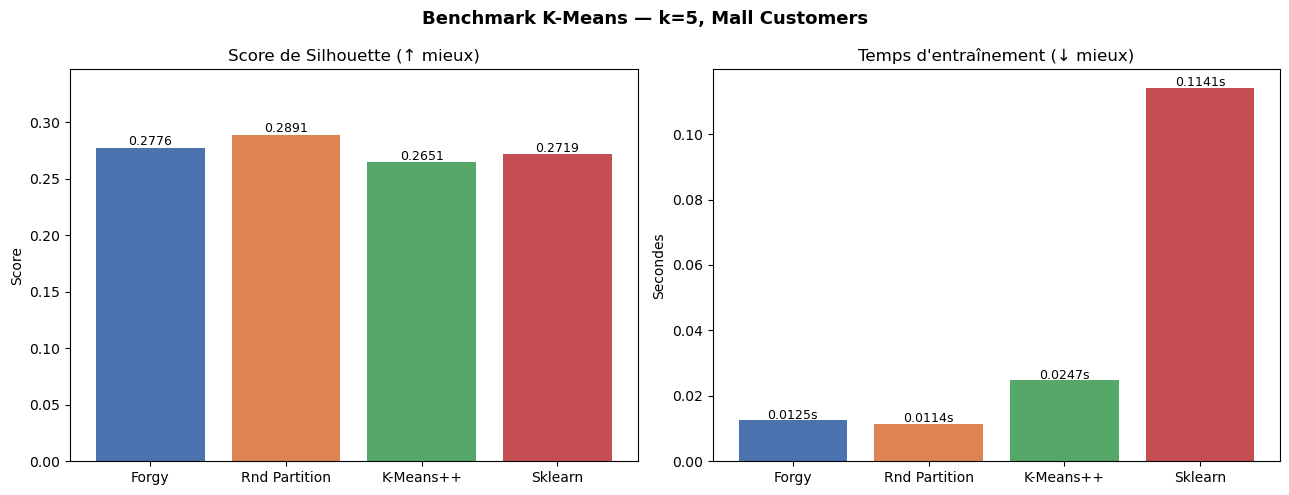

In [10]:
# Visualisation — Silhouette & Temps d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
labels = ["Forgy", "Rnd Partition", "K-Means++", "Sklearn"]

# Silhouette
axes[0].bar(labels, benchmark_df["Silhouette"].values, color=colors)
axes[0].set_title("Score de Silhouette (↑ mieux)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, max(benchmark_df["Silhouette"].values) * 1.2)
for i, v in enumerate(benchmark_df["Silhouette"].values):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha='center', fontsize=9)

# Temps
axes[1].bar(labels, benchmark_df["Temps (s)"].values, color=colors)
axes[1].set_title("Temps d'entraînement (↓ mieux)")
axes[1].set_ylabel("Secondes")
for i, v in enumerate(benchmark_df["Temps (s)"].values):
    axes[1].text(i, v + 0.0005, f"{v:.4f}s", ha='center', fontsize=9)

plt.suptitle("Benchmark K-Means — k=5, Mall Customers", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()